In [1]:
import sys
import os
import matplotlib.pyplot as plt
%matplotlib widget
import numpy as np

from os import path

from IPython.display import clear_output
from copy import deepcopy

import gvar as gv

# Fitting Procedure

## Define parameters

### Directory and stuff

In [2]:
p = dict()
p["debug"]   = False
p["verbose"] = False
p["latex"]   = True
p["save"] = True
p["fitter"] = 'scipy_least_squares'
p["fpath"] = {"nucleon": "./data/cosmon_c103_r005-8_nucleon.hdf5", 
                "nn": "./data/cosmon_c103_r005-8_deuteron_Swave.hdf5"}

### Looping Parameters

The parameters here can and will be looped over. This block and the next covers all the bash script functionality. 

In [3]:
''' Feeds p["t0"] '''
pt0     = [5]
''' Feeds p["td"] '''
ptd     = [10]
''' Feeds p["nstates"] '''
pnN     = [3]
''' Feeds p["block"] '''
pblock  = [2]
''' Feeds p["trange"] N part '''
pN      = [3]
''' Feeds p["trange"] R part '''
pR      = [3,4,5]

### Crucial Parameters

I only call these crucial as I have seen them changed, or could possibly be changed. 

In [4]:
p['t_norm']         = 3
p['gevp']           = 'evp' # evp or gevp
p["ratio"]          = False
p["version"]        = 'conspire'
p["r_n_el"]         = 0

In [5]:
p['get_Zj']         = True
if 'deuteron' in p["fpath"]["nn"]:
    p['Zjn_values'] = f"result/deuteron_Zjn_tNorm{p['t_norm']}_{p['gevp']}.h5"
elif 'dineutron' in p["fpath"]["nn"]:
    p['Zjn_values'] = f"result/dineutron_Zjn_tNorm{p['t_norm']}_{p['gevp']}.h5"
p['show_Zjn']       = False
p['do_gevp']        = False #set to True if you want to do gevp if it was already done and saved

### Bootstrap Parameters

In [6]:
p["bootstrap"] = False
p['Nbs_max']   = 5000
p["nbs"]       = 5000
p["nbs_sub"]   = 100
p['bs0_width'] = 5
p['bs_prior']  = 'all' # 'gs' or 'all': 
                      # randomize prior mean for gs or all priors
#p['old_bs']    = True # set to True to use BS list from 2009.11825

### Parameters That I Don't Know What to Do With (For Now)

In [7]:
#p['cfgs']  = [0,802[,1]] # use this to cut configs if desired 

p['svd_study'] = False
p['svdcut']    = 1e-8

p["autotime"]   = 10 # time used to estimate mean gs energy prior
p["sig_e0"]     = 1 # multiplication factor for meff[autotime] for prior width for deltaE_gs
p["sig_enn"]    = 1 # multiplication factor for meff[autotime] for prior width for deltaE_nn
p["positive_z"] = True

p["ratio_type"]  = "data"
p["irreps"]      = "irreps_ben" #["irreps", "irreps_ben"]

p["gs_conspire"] = False # only add deltaE for ground state?
p["r_n_inel"]    = 2

p["ampi"] = 0.310810
p["amn"]  = 0.70262
p["dE_elastic"] = 2 * np.sqrt(p["amn"]**2 + 1 * (2 * np.pi / 48) ** 2) -2*p["amn"]

## Define Irrep to Fit

Comment out the long list and copy paste desired irrep into the shorter dict to choose 1 specific irrep. It should be of the form: 

    p["masterkey"] = [ [(irrep)] ].

Choose to fit all or fit 1. There are issues if you just fit 1 stated in the readme. 

In [8]:
# p["masterkey"] = [
#     [("0", "T1g", 0)], [('0', 'T1g', 1)],
#     [('1', 'A2', 0)], [('1', 'A2', 1)], 
#     [('1', 'E', 0)], [('1', 'E', 1)], [('4', 'E', 0)], [('4', 'E', 1)],
#     [('2', 'A2', 0)], [('4', 'A2', 0)], [('4', 'A2', 1)], 
#     [('2', 'B1', 0)], [('2', 'B2', 0)], [('2', 'B2', 3)],
#     [('3', 'A2', 0)], [('3', 'A2', 1)], [('3', 'E', 0)]
#     ]

p["masterkey"] = [ [('1', 'A2', 0)] ]

# Fitting

In [9]:
import nn_fit as fit
for i in range(len(pt0)):
    for j in range(len(pblock)):
        for k in range(len(pnN)): 
            for l in range(len(pN)):
                for m in range(len(pR)):
                    p["t0"]     = pt0[i]
                    p["td"]     = ptd[i]
                    p["block"]  = pblock[j] 
                    p['bs_seed']   = 'nn_c103_b%d' %p["block"]
                    p["nstates"]    = pnN[k]
                    p["trange"]      = {"N": [pN[l], 20], "R": [pR[m], 15]}
                    fit.main(p)
                    plt.close("all")
                    clear_output()

print("Fitting Completed")

Fitting Completed


# Plotting Procedure

### Main Plotting Parameters

In [10]:
''' v0.1.1: 
Currently only supports plotting 1 or all.
Put in 1 irrep to plot just 1 irrep. Toggle PlotAll to True to plot every irrep (potentially takes minutes). 
'''

''' Deuteron irreps:
    [("0", "T1g", 0)], [('0', 'T1g', 1)],
    [('1', 'A2', 0)], [('1', 'A2', 1)], 
    [('1', 'E', 0)], [('1', 'E', 1)], [('4', 'E', 0)], [('4', 'E', 1)],
    [('2', 'A2', 0)], [('4', 'A2', 0)], [('4', 'A2', 1)], 
    [('2', 'B1', 0)], [('2', 'B2', 0)], [('2', 'B2', 3)],
    [('3', 'A2', 0)], [('3', 'A2', 1)], [('3', 'E', 0)]     '''

irrep = [("0", "T1g", 0)]    # Copy & paste with brackets. Should look like [(irrep)]. 

''' Plot every irrep. 
    v0.1.1: Overrides the single plot due to UseFitParams, and the irrep selection above. 
 '''
PlotAll         = False # True False

''' Clear text output for plotting cell '''
PlotClearText   = True # True False

''' ------ Auto-fill flags ------ '''
''' Set to true to auto-fill all relevant parameters for plotting. '''

''' Auto-fill all "fit file directory" and "additional" parameters using the fitting parameters. '''
''' v0.1.1: If you decided to fit everything. It will default to ("0", "T1g", 0). 
            It displays the 1st fit done. That is the 1st element in the "looping parameters". 
'''
UseFitParams    = True # True False

''' Auto-fill all "additional" plotting parameters with defaults. Will overwrite "additional" parts of UseFitParams. '''
UseDefaults     = True # True False

### Fit File Directory Parameters
You can skip doing this and go to plot cell -- cell with plot in text above it -- and copy paste the file name into there.

In [11]:
''' System. 'dineutron' or 'deuteron' '''
nn_iso  = 'deuteron'

''' gevp time. In the form 't0-td' '''
ft0td   = '4-8'

''' 'conspire' or 'agnostic' '''
fagcons = 'conspire'

''' t_norm. In the form 'int' '''
ftnorm  = 3

''' block '''
fblock  = 8

''' N part of t_range. The number before 20. '''
fN      = 4

''' R part of t_range. The number before 15. '''
fR      = 2

''' Ratio '''
fRatio  = False

''' r_n_el '''
fe      = 0

''' nstates '''
fnN     = 3

### Additional Plotting Parameters

In [12]:
''' Number of exponentials in single nucleon to sweep over. Default: [3] '''
n_N     = [2,3,4]   
''' Number of elastic e.s. to try.                          Default: [0] '''
nn_el   = [0]    
''' List of GEVP times in t0-td format                      Default: ['4-8', '4-10', '5-10','5-12', '6-10', '6-12'] '''
gevp    = ['4-8', '4-10', '5-10','5-12', '6-10', '6-12']      
''' Values of t_min in NN fit.                              Default: range(2,9) '''
tmin    = range(2,9)

''' Fit from RATIO correlator?                              Default: False '''
ratio   = False
''' Load evp (vs gevp) data?                                Default: True '''
evp     = True
''' Use gs only conspiracy model?                           Default: False '''
gs_cons = False

''' The 3 below are not covered by UseFitParams'''

''' What type of figure?    Types: "pdf" , "png"            Default: "pdf" '''
fig_type= "pdf"

''' If test==True, only do T1g                              Default: False '''
test    = False
''' Add extra debug print statements?                       Default: False '''
debug   = False

### Auto-fill Cell

In [13]:
if UseFitParams:
    irrep   = p["masterkey"][0]

    ''' File Directory'''
    if 'deuteron' in p["fpath"]["nn"]:
        nn_iso  = 'deuteron'
    elif 'dineutron' in p["fpath"]["nn"]:
        nn_iso  = 'dineutron'
    ft0td   = f"{pt0[0]}-{ptd[0]}"
    fagcons = deepcopy(p["version"])
    ftnorm  = deepcopy(p["t_norm"])
    fblock  = f"{pblock[0]}"
    fN      = f"{pN[0]}"
    fR      = f"{pR[0]}"
    fRatio  = deepcopy(p["ratio"])
    fe      = deepcopy(p["r_n_el"])
    fnN     = f"{pnN[0]}"

    ''' Additional Parameters'''
    n_N     = deepcopy(pnN)
        
    nn_el   = [deepcopy(p["r_n_el"])]

    gevp    = []
    for t0, td in zip(pt0, ptd):
        gevp.append(f"{t0}-{td}")

    tmin    = deepcopy(pN)

    ratio   = deepcopy(p["ratio"])

    if p["gevp"] == "evp":
        evp = True
    else: evp = False

    gs_cons = deepcopy(p["gs_conspire"])

if PlotAll:
    irrep = []

if UseDefaults:
    for var in ["n_N","nn_el","ratio","gevp","evp","tmin","gs_cons","fig_type","test","debug"]:
        if var in locals():
            del locals()[var]

### Plot

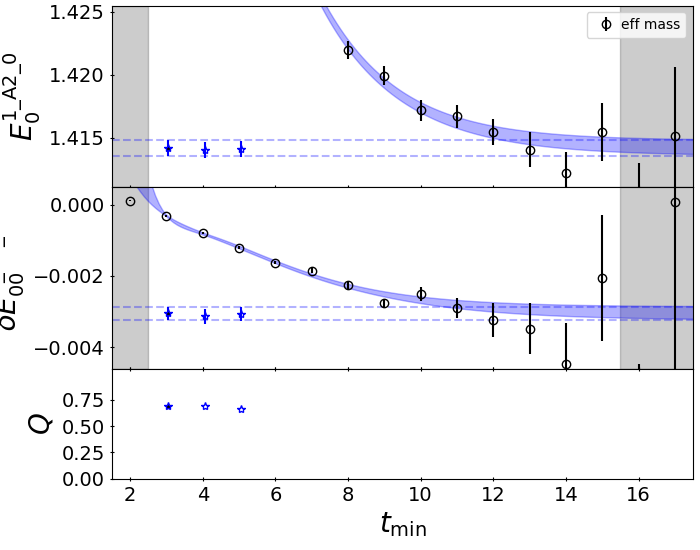

In [14]:
import plot_nn_stability_gevp as plotgevp

filename = f"result/NN_{nn_iso}_tnorm{ftnorm}_t0-td_{ft0td}_N_n{fnN}_t_{fN}-20_NN_{fagcons}_e{fe}_t_{fR}-15_ratio_{fRatio}_block{fblock}.pickle"
argv = [
    "plot_nn_stability_gevp.py",
    filename
] 

# argv = [
#     "plot_nn_stability_gevp.py",
#     "result/NN_deuteron_tnorm3_t0-td_4-8_N_n3_t_4-20_NN_conspire_e0_t_2-15_ratio_False_block8.pickle"
# ]   # Comment out the 1st argv and uncomment this argv. 
    # Copy & paste the file name after result/ into space above to circumvent the "fit file parameter" portion.  

if 'n_N' in locals():
    argv += ["--n_N"] + [str(x) for x in n_N]

if 'nn_el' in locals():
    argv += ["--nn_el"] + [str(x) for x in nn_el]

if 'gevp' in locals():
    argv += ["--gevp"] + [str(x) for x in gevp]

if 'tmin' in locals():
    argv += ["--tmin"] + [str(x) for x in tmin]

if 'fig_type' in locals():
    argv += ["--fig_type", fig_type]

if 'ratio' in locals():
    if ratio:
        argv.append("--ratio")

if 'evp' in locals():
    if not evp:
        argv.append("--evp")

if 'gs_cons' in locals():
    if gs_cons:
        argv.append("--gs_cons")

if 'test' in locals():
    if test:
        argv.append("--test")

if 'debug' in locals():
    if debug:
        argv.append("--debug")

sys.argv = argv

plotgevp.main(params=irrep)

if PlotClearText:
    clear_output()

plt.show()

### Summary Plot

In [15]:
runcell = False # This cell works, but the plotting files has not been changed to run if there isnt a T1g fit. 
# If you run it for a T1g fit, this will run

if runcell:
    argv.append("--summary")

    irrep = []

    plotgevp.main(params=irrep)

    if PlotClearText:
        clear_output()

    plt.show()

# Fit Parameters & Quality of Fit Metrics

### Auto-fill Flags

In [16]:
UsePlotParams = True # Displays the parameters and metrics of the contents in the plot. 

### v0.1.1 Testing

In [17]:
''' if useplot true'''
fit_file = filename

data = gv.load(fit_file)

print("\nAll keys in the file:")
for k in data.keys():
    print(k)


All keys in the file:
masterkey
((('1', 'A2', 0), 'N', '0'), 'e0')
((('1', 'A2', 0), 'N', '0'), 'z0')
((('1', 'A2', 0), 'N', '0'), 'e1')
((('1', 'A2', 0), 'N', '0'), 'z1')
((('1', 'A2', 0), 'N', '0'), 'e2')
((('1', 'A2', 0), 'N', '0'), 'z2')
((('1', 'A2', 0), 'N', '1'), 'e0')
((('1', 'A2', 0), 'N', '1'), 'z0')
((('1', 'A2', 0), 'N', '1'), 'e1')
((('1', 'A2', 0), 'N', '1'), 'z1')
((('1', 'A2', 0), 'N', '1'), 'e2')
((('1', 'A2', 0), 'N', '1'), 'z2')
((('1', 'A2', 0), 'R', ('0', '1')), 'e0')
((('1', 'A2', 0), 'R', ('0', '1')), 'z0')
((('1', 'A2', 0), 'R', ('0', '1')), 'e_0_1')
((('1', 'A2', 0), 'R', ('0', '1')), 'z_0_1')
((('1', 'A2', 0), 'R', ('0', '1')), 'e_0_2')
((('1', 'A2', 0), 'R', ('0', '1')), 'z_0_2')
((('1', 'A2', 0), 'R', ('0', '1')), 'e_1_0')
((('1', 'A2', 0), 'R', ('0', '1')), 'z_1_0')
((('1', 'A2', 0), 'R', ('0', '1')), 'e_1_1')
((('1', 'A2', 0), 'R', ('0', '1')), 'z_1_1')
((('1', 'A2', 0), 'R', ('0', '1')), 'e_1_2')
((('1', 'A2', 0), 'R', ('0', '1')), 'z_1_2')
((('1', 'A2',

In [18]:
print(data[((('1', 'A2', 0),), 'Q')])

0.6911199640667047


### Plain Text

### Plots

# This has not been fixed to work for arbitrary channels yet.

In [19]:
import sys
sys.argv = ["print_params.py", "result_old/NN_deuteron_tnorm3_t0-td_4-8_N_n3_t_4-20_NN_conspire_e0_t_2-15_ratio_False_block8.pickle"]

!python print_params.py "result_old/NN_deuteron_tnorm3_t0-td_4-8_N_n3_t_4-20_NN_conspire_e0_t_2-15_ratio_False_block8.pickle"

('0', 'T1g', 1)
single nucleon params
---------------------------------------------------------------
   e0        0.71428(37)    [ 0.720(72) ]
   e1         -0.765(75)    [ -0.48(70) ]
   e2          -0.49(17)    [ -0.48(70) ]
   z0        0.42602(75)    [ 0.43(43) ]
   z1          0.644(54)    [ 1.00(25) ]
   z2          0.785(73)    [ 1.00(25) ]

('0', 'T1g', 1) params
---------------------------------------------------------------
['e0', 'e_0_1', 'e_0_2', 'e_1_0', 'e_1_1', 'e_1_2', 'e_2_0', 'e_2_1', 'e_2_2', 'z0', 'z_0_1', 'z_0_2', 'z_1_0', 'z_1_1', 'z_1_2', 'z_2_0', 'z_2_1', 'z_2_2']
   e0       -0.00376(18)    [ -0.0036(36) ]
e_0_1        -0.0013(36)    [ 0 ± 0.0036 ]
e_0_2       0.00008(360)    [ 0 ± 0.0036 ]
e_1_0        -0.0013(36)    [ 0 ± 0.0036 ]
e_1_1       0.00009(360)    [ 0 ± 0.0036 ]
e_1_2       0.00001(360)    [ 0 ± 0.0036 ]
e_2_0       0.00008(360)    [ 0 ± 0.0036 ]
e_2_1       0.00001(360)    [ 0 ± 0.0036 ]
e_2_2       0.00001(360)    [ 0 ± 0.0036 ]
   z0         16